<a href="https://colab.research.google.com/github/eniompw/microgpt/blob/main/microgpt_lite.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MicroGPT — Lite (Colab T4 GPU)

Minimal GPT in pure PyTorch with key speed improvements: flash attention, RoPE, `torch.compile`, mixed precision, fused AdamW.

> **Runtime:** Go to **Runtime → Change runtime type → T4 GPU** before running.

## 1. GPU Setup and Library Imports

In [ ]:
import os, random, json, math, time
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

random.seed(42); torch.manual_seed(42)  # reproducibility
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"device: {device}" + (f" | {torch.cuda.get_device_name(0)}" if device.type == 'cuda' else ''))

device: cuda | Tesla T4


## 2. Dataset and Tokenizer

In [ ]:
if not os.path.exists('input.txt'):
    import warnings, pandas as pd
    warnings.filterwarnings('ignore', category=UserWarning, module='huggingface_hub')
    df = pd.read_parquet("hf://datasets/karpathy/tinystories-gpt4-clean/tinystories_gpt4_clean.parquet")
    with open('input.txt', 'w') as f:
        for s in df['text'].iloc[20000:25000]:
            f.write(json.dumps(s) + '\n')

docs = [json.loads(l) for l in open('input.txt') if l.strip()]
random.shuffle(docs)

# Character-level vocab — 74 printable ASCII chars + BOS (beginning-of-story) token
uchars = sorted('\n !"$\',-.' + '0123456789:;?' + 'ABCDEFGHIJKLMNOPQRSTUVWXYZ' + 'abcdefghijklmnopqrstuvwxyz')
BOS = len(uchars); vocab_size = BOS + 1
stoi = {c: i for i, c in enumerate(uchars)}
encode = lambda s: [stoi[c] for c in s]
decode = lambda ids: ''.join(uchars[i] for i in ids)
print(f"docs: {len(docs)}, vocab: {vocab_size}, sample: {docs[0][:80]}...")

docs: 5000, vocab: 75, sample: Ben and Lily were playing in the farm with their new friend, Mira the mule. Mira...


## 3. Model Parameters

In [ ]:
# Hyperparameters
n_layer, n_embd, block_size, n_head = 6, 256, 256, 8
head_dim = n_embd // n_head
batch_size = 64

# Weight init — scale down randn; .requires_grad_(True) on result makes it an optimisable leaf tensor
W = lambda r, c: (torch.randn(r, c, device=device) * 0.02).requires_grad_(True)
sd = {'wte': W(vocab_size, n_embd)}  # token embeddings — reused as lm_head (weight tying)
for i in range(n_layer):
    sd |= {f'l{i}.wq': W(n_embd, n_embd), f'l{i}.wk': W(n_embd, n_embd),  # attention Q, K, V, O
           f'l{i}.wv': W(n_embd, n_embd), f'l{i}.wo': W(n_embd, n_embd),
           f'l{i}.fc1': W(4*n_embd, n_embd), f'l{i}.fc2': W(n_embd, 4*n_embd)}  # MLP
params = list(sd.values())
print(f"params: {sum(p.numel() for p in params):,}")

params: 4,737,792


## 4. Model Architecture

In [ ]:
def rmsnorm(x):
    return x * (x.pow(2).mean(-1, keepdim=True) + 1e-5).rsqrt()  # normalise without mean subtraction

# RoPE — precompute cos/sin rotation tables once; reused every forward pass
t = torch.arange(block_size, device=device).float()
f = 1.0 / (10000.0 ** (torch.arange(0, head_dim, 2, device=device).float() / head_dim))
rope_cos, rope_sin = torch.outer(t, f).cos(), torch.outer(t, f).sin()  # (block_size, head_dim//2)

def apply_rope(x, cos, sin):
    # Rotate pairs of dimensions to encode relative position into q/k vectors
    d = x.dtype
    x = x.float().unflatten(-1, (-1, 2))  # split last dim into (head_dim//2, 2) pairs
    x0, x1 = x[..., 0], x[..., 1]
    cos = cos.view(1, -1, 1, cos.shape[-1])
    sin = sin.view(1, -1, 1, sin.shape[-1])
    return torch.stack([x0*cos - x1*sin, x0*sin + x1*cos], -1).flatten(-2).to(d)

def forward(tokens):
    """tokens: (B, T) long → logits (B, T, vocab_size)"""
    B, T = tokens.shape
    x = rmsnorm(F.embedding(tokens, sd['wte']))
    cos, sin = rope_cos[:T], rope_sin[:T]
    for i in range(n_layer):
        # Attention block
        r = x; x = rmsnorm(x)
        q = F.linear(x, sd[f'l{i}.wq']).view(B, T, n_head, head_dim)
        k = F.linear(x, sd[f'l{i}.wk']).view(B, T, n_head, head_dim)
        v = F.linear(x, sd[f'l{i}.wv']).view(B, T, n_head, head_dim)
        q, k = apply_rope(q, cos, sin), apply_rope(k, cos, sin)
        x = F.scaled_dot_product_attention(             # flash attention — fused CUDA kernel
            q.transpose(1,2), k.transpose(1,2), v.transpose(1,2), is_causal=True
        ).transpose(1,2).reshape(B, T, -1)
        x = F.linear(x, sd[f'l{i}.wo']) + r            # output projection + residual
        # MLP block
        r = x; x = rmsnorm(x)
        x = F.silu(F.linear(x, sd[f'l{i}.fc1']))       # SiLU activation (smoother than ReLU)
        x = F.linear(x, sd[f'l{i}.fc2']) + r
    return F.linear(rmsnorm(x), sd['wte'])              # weight-tied lm_head

forward = torch.compile(forward)  # fuse GPU kernels for ~2× speedup
print("model ready")

model ready


## 5. Training Loop

W0407 12:33:42.789000 3439 torch/_inductor/utils.py:1679] [0/0] Not enough SMs to use max_autotune_gemm mode


step    0/3500 | loss 5.2415 | lr 0.00e+00 | 16.7s
step  100/3500 | loss 2.1986 | lr 5.00e-04 | 36.1s
step  200/3500 | loss 1.5614 | lr 1.00e-03 | 40.9s
step  300/3500 | loss 1.2520 | lr 9.98e-04 | 45.8s
step  400/3500 | loss 1.1324 | lr 9.92e-04 | 50.8s
step  500/3500 | loss 1.0967 | lr 9.82e-04 | 55.7s
step  600/3500 | loss 1.0160 | lr 9.68e-04 | 60.8s
step  700/3500 | loss 0.9500 | lr 9.50e-04 | 65.8s
step  800/3500 | loss 0.9186 | lr 9.29e-04 | 70.9s
step  900/3500 | loss 0.9249 | lr 9.04e-04 | 76.0s
step 1000/3500 | loss 0.9001 | lr 8.76e-04 | 81.1s
step 1100/3500 | loss 0.8447 | lr 8.45e-04 | 86.4s
step 1200/3500 | loss 0.8385 | lr 8.11e-04 | 91.7s
step 1300/3500 | loss 0.8077 | lr 7.75e-04 | 97.0s
step 1400/3500 | loss 0.7972 | lr 7.37e-04 | 102.4s
step 1500/3500 | loss 0.7821 | lr 6.97e-04 | 107.8s
step 1600/3500 | loss 0.7559 | lr 6.56e-04 | 113.4s
step 1700/3500 | loss 0.7425 | lr 6.14e-04 | 118.9s
step 1800/3500 | loss 0.7653 | lr 5.71e-04 | 124.5s
step 1900/3500 | loss 0.71

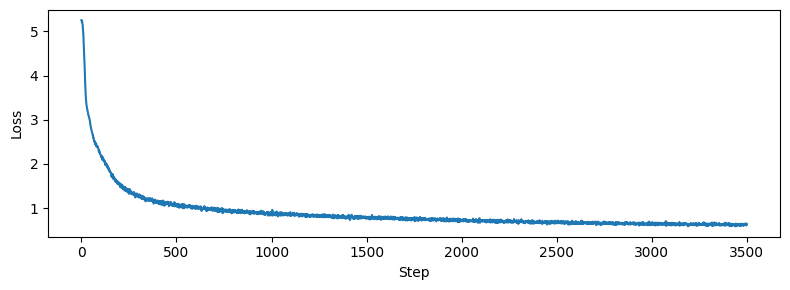

In [ ]:
# Flatten all stories into a single token stream with BOS markers as story boundaries
all_tokens = torch.tensor(
    [t for doc in docs for t in [BOS] + encode(doc)] + [BOS],
    dtype=torch.long, device=device
)

def get_batch():
    # Sample batch_size random windows of block_size tokens from the stream
    s = torch.randint(0, len(all_tokens) - block_size - 1, (batch_size,), device=device)
    idx = s.unsqueeze(1) + torch.arange(block_size + 1, device=device)
    t = all_tokens[idx]
    return t[:, :-1], t[:, 1:]  # inputs, targets (shifted by 1 for next-token prediction)

num_steps, warmup, lr, min_lr = 3500, 200, 1e-3, 1e-4

def get_lr(step):
    # Linear warmup then cosine decay to min_lr floor
    if step < warmup:
        return lr * step / warmup
    p = (step - warmup) / (num_steps - warmup)
    return min_lr + (lr - min_lr) * 0.5 * (1 + math.cos(math.pi * p))

opt = torch.optim.AdamW(params, lr=lr, betas=(0.9, 0.95), eps=1e-10, fused=(device.type == 'cuda'))
scaler = torch.amp.GradScaler('cuda')  # scales loss to prevent float16 gradient underflow
losses, t0 = [], time.time()

for step in range(num_steps + 1):
    opt.param_groups[0]['lr'] = get_lr(step)  # update LR each step
    if step % 100 == 0:
        xb, yb = get_batch()
        with torch.no_grad(), torch.amp.autocast('cuda', dtype=torch.float16):
            loss_val = F.cross_entropy(forward(xb).reshape(-1, vocab_size), yb.reshape(-1)).item()
        print(f"step {step:4d}/{num_steps} | loss {loss_val:.4f} | lr {get_lr(step):.2e} | {time.time()-t0:.1f}s")
    if step >= num_steps: break
    opt.zero_grad(set_to_none=True)
    xb, yb = get_batch()
    with torch.amp.autocast('cuda', dtype=torch.float16):
        loss = F.cross_entropy(forward(xb).reshape(-1, vocab_size), yb.reshape(-1))
    scaler.scale(loss).backward()
    scaler.unscale_(opt)
    torch.nn.utils.clip_grad_norm_(params, 1.0)  # prevent loss spikes from large gradients
    scaler.step(opt); scaler.update()
    losses.append(loss.item())

print(f"\nDone in {time.time()-t0:.1f}s")
plt.figure(figsize=(8, 3))
plt.plot(losses); plt.xlabel('Step'); plt.ylabel('Loss'); plt.tight_layout(); plt.show()

## 6. Inference and Text Generation

In [ ]:
def generate(max_tokens=200, temperature=0.7):
    tokens = [BOS]
    with torch.no_grad():
        for _ in range(max_tokens):
            x = torch.tensor([tokens[-block_size:]], device=device)  # sliding window context
            logits = forward(x)[0, -1, :vocab_size]
            next_id = torch.multinomial(F.softmax(logits / temperature, -1), 1).item()
            if next_id == BOS: break  # end of story
            tokens.append(next_id)
    return decode(tokens[1:])

t0 = time.time()
for i in range(5):
    print(f"--- sample {i+1} ---\n{generate()}\n")
print(f"Done in {time.time()-t0:.1f}s")

--- sample 1 ---
Once upon a time, there was a big girl named Amy. She loved to talk and speak. She had many friends who never play on the ground. One day, she wanted to play with her parents, so she took her to the b

--- sample 2 ---
Once upon a time, there was a little girl named Amy. She loved to play with her toys and make cakes it. One day, she found a big hole in her room. She wanted to show her friends, but she was so excite

--- sample 3 ---
One day, a little boy named Tim went to introduce his favorite toy. He was very excited to be mad. He saw a big candle with many everyone. Tim thought it would be fun to play with.
Tim picked up the t

--- sample 4 ---
One day, a little boy named Tim went to the park. He saw a big tree with a hurt cat. The bird had a friend named Tim. Tim was a big tree. Tim wanted to help his mom.
Tim went to his friend, Sam. He ra

--- sample 5 ---
Once upon a time, there was a little boy named Tim. He loved to measure his head. One day, he found a small